## Étape 2 : Assemble Data

In [5]:
from datasets import load_dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import json
from dotenv.ipython import load_dotenv
from langchain_openai import ChatOpenAI
from tqdm import tqdm

In [6]:
ds=load_dataset("imdb")

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [8]:
train_df=ds["train"].to_pandas()

In [9]:
train_df.sample(10)

,text,label
20470,I am curious of what rifle Beckett was using i...,1
13016,I went to a small advance screening of this mo...,1
5361,"We had to go to an appointment, so we turned o...",0
20494,I bought this game on eBay having heard that i...,1
14088,The bittersweet twist to this movie contains a...,1
16273,The first film had little ambition so nothing ...,1
4561,Rather foolish attempt at a Hitchcock-type mys...,0
9950,In A Woman Under the Influence Mabel goes craz...,0
21938,A surprise thriller with more twists and doubl...,1
463,This movie had the potential to be far more th...,0


In [10]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [11]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [12]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [13]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

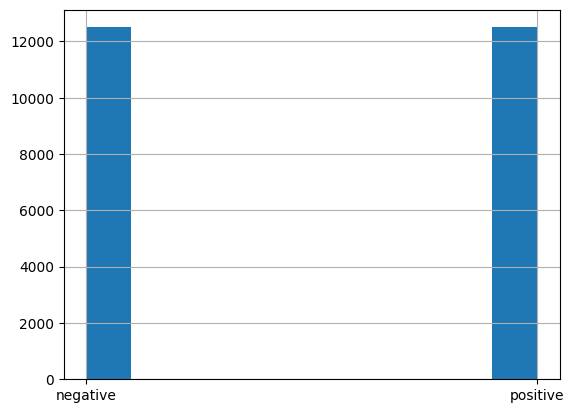

In [14]:
train_df.sentiment.hist()

In [15]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [16]:
examples_df.shape , gold_examples_df.shape

((20000, 3), (5000, 3))

In [17]:
columns=["text","sentiment"]
gold_examples= (gold_examples_df[columns]
                .sample(20, random_state=34)
                .to_json(orient="records")
                )

In [18]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

## Étape 3 : Élaborer le prompt

In [19]:
user_prompt_template = """```{movie_review}```"""

In [20]:
zero_shot_system_message =""""
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [21]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

In [22]:
few_shot_system_message ="""
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

In [23]:
examples_df.shape

(20000, 3)

In [24]:
positive_reviews_df=(examples_df[examples_df['sentiment']=='positive'][columns]
                     .sample(4, random_state=34)
                     )

In [25]:
negative_reviews_df=(examples_df[examples_df['sentiment']=='negative'][columns]
                     .sample(4, random_state=34)
                     )

In [26]:
negative_reviews_df

,text,sentiment
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative


In [27]:
positive_reviews_df

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive


In [28]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [29]:
ex=pd.concat([positive_reviews_df, negative_reviews_df])

In [30]:
ex

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative


In [31]:
examples= examples_df.sample(4*2, replace=False).to_json(orient="records")

In [32]:
json.loads(examples)

[{'text': 'I guess that "Gunslinger" wasn\'t quite as god-awful as most of the movies that "Mystery Science Theater 3000" shows, but westerns just aren\'t Roger Corman\'s forte. Portraying Rose Hood (Beverly Garland) becoming sheriff in an Old West town after her sheriff husband gets murdered and having to fight off baddies, the movie is pretty predictable. John Ireland is Rose\'s new hubby, secretly working for unctuous Allison Hayes (yes, the 50-foot woman). Also appearing briefly is frequent Corman co-star Dick Miller as a mailman (Miller nowadays stars in Joe Dante\'s movies).<br /><br />I do wish to assert that you\'ll probably want to watch the "MST3K" version to really enjoy this movie. They had a great time with it.',
  'label': 0,
  'sentiment': 'negative'},
 {'text': 'If you are looking for a film the portrays the pointless and boring existence of middle class lives caught in a web of non-communication and false ideals, then this is the film for you. If you also what the film

In [33]:
def create_examples(dataset, n=4):
    positive_reviews_df=(dataset[dataset['sentiment']=='positive'][columns]
                     .sample(n, random_state=34)
                     )
    negative_reviews_df=(dataset[dataset['sentiment']=='negative'][columns]
                     .sample(n, random_state=34)
                     )
    examples_df=pd.concat([positive_reviews_df, negative_reviews_df])
    examples= examples_df.sample(2*n, replace=False)
    return examples.to_json(orient="records")

In [34]:
examples_df.shape

(20000, 3)

In [35]:
few_shot_examples=create_examples(examples_df, n=2)


In [36]:
json.loads(few_shot_examples)

[{'text': 'Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br /><br />This is just another excercise in self-importance from the kids who never really grew up.',
  'sentiment': 'negative'},
 {'text': 'This movie is so awful, it is hard to find the right words to describe it!<br /><br />At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br /><br />The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for 

In [53]:
def creat_prompt(system_message, examples, user_prompt_template):
    prompt=[
        {'role':'system', 'content': system_message},
    ]
    for example in json.loads(examples) :
        review=example['text']
        sentiment=example['sentiment']
        prompt.append({'role':'user', 'content': user_prompt_template.format(movie_review=review) })
        prompt.append({'role':'assistant', 'content': f"{sentiment}"})
    return prompt

In [38]:
few_shot_prompt = creat_prompt(few_shot_system_message, few_shot_examples, user_prompt_template)

In [39]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br /><br />This is just another excercise in self-importance from the kids who never really grew up.```'},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': '```This movie is so awful, it is hard to find the right words to d

## Etape 4 : Evaluate Prompts

In [40]:
cot_few_shot_prompt_system_message = """
Classify the sentiment of movie reviews presented in the input
as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the
input.
Answer only 'positive' or 'negative'
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive 

To reiterate, your answer should strictly only contain the label: positive or negative

"""

In [41]:
cot_few_shot_prompt= creat_prompt(cot_few_shot_prompt_system_message
                                  ,few_shot_examples
                                  ,user_prompt_template)

In [42]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input\nas 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the\ninput.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive \n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n\n"},
 {'role': 'user',
  'content': '```Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic

In [43]:
from sklearn.metrics import f1_score

In [55]:
def evaluate_prompt(prompt,gold_examples,user_prompt_template,llm):
    predicted_sentiments=[]
    ground_truth_sentiment = []
    for exemple in json.loads(gold_examples):
        review= exemple['text']
        sentiment = exemple['sentiment']
        user_input = [{"role" :"user" , "content" : user_prompt_template.format(movie_review=review)}]
        try :
            resp=llm.invoke(prompt+user_input)
            if 'negative' in resp.content.strip().lower():
                predicted= 'negative'
            elif 'positive' in resp.content.strip().lower():
                predicted= 'positive'
            else :
                predicted='unknown'
            predicted_sentiments.append(predicted)
            ground_truth_sentiment.append(sentiment)
            #print (predicted, sentiment)
        except Exception as e :
            print(e)
            continue
    return f1_score(ground_truth_sentiment,predicted_sentiments,average='micro')
    
    

In [45]:
load_dotenv(override=True)

True

In [46]:
llm1 = ChatOpenAI(model="gpt-4o",temperature=0)

In [47]:
evaluate_prompt(zero_shot_prompt,gold_examples , user_prompt_template ,llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [50]:
evaluate_prompt(few_shot_prompt,gold_examples , user_prompt_template ,llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
negative positive
positive positive
negative negative


0.9

In [49]:
evaluate_prompt(cot_few_shot_prompt,gold_examples , user_prompt_template ,llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
negative positive
positive positive
negative negative


0.9

In [ ]:
from langchain_ollama import ChatOllama

In [ ]:
llm2 = ChatOllama(model="llama3.2", temperature=0)  

In [ ]:
evaluate_prompt(cot_few_shot_prompt,gold_examples , user_prompt_template ,llm2)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [ ]:
evaluate_prompt(zero_shot_prompt,gold_examples , user_prompt_template ,llm2)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [ ]:
evaluate_prompt(few_shot_prompt,gold_examples , user_prompt_template ,llm2)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [56]:
num_evel_runs=10
performances=[]

for _ in tqdm(range(num_evel_runs)) :
    examples = create_examples(examples_df,n=4)
    fsp = creat_prompt(few_shot_system_message,examples, user_prompt_template)
    score=evaluate_prompt(fsp,gold_examples,user_prompt_template,llm1)
    performances.append(score)

mean= np.array(performances).mean()
std= np.array(performances).std()

print(f"Mean : {mean} , std : {std}")


 90%|█████████ | 9/10 [12:08<01:22, 82.62s/it]

Connection error.
Connection error.
Connection error.
Connection error.


100%|██████████| 10/10 [14:36<00:00, 87.69s/it] 

Mean : 0.9549999999999998 , std : 0.015000000000000015
